# YouTube Spam Classifier 

## Environment Setup
This notebook requires the following libraries:
- pandas, numpy, matplotlib, scikit-learn, openpyxl

Install with: `pip install pandas numpy matplotlib scikit-learn openpyxl`

## Data Files
Place the following files in the same folder as this notebook:
- `Topic1-youtube_spam_train.csv`
- `Topic1-youtube_spam_test.xlsx`

## Run Instructions
Run the below cells for result, it will take around 1-2 minutes for the hole cell to run.

## Output
- `predictions.csv` - Test set predictions
- `model_comparison.png` - Model comparison chart


Training data size: (798, 5)
Test data size: (202, 5)

Training data columns: ['VIDEO', 'AUTHOR', 'DATE', 'TEXT', 'CLASS']
Test data columns: ['VIDEO', 'AUTHOR', 'DATE', 'TEXT', 'CLASS']

Model Evaluation with 5-fold Cross Validation

---------------Logistic Regression----------------
  Cross-validation accuracy: 0.7920
  Training accuracy: 0.9536
  Test accuracy: 0.8465
  Weighted F1-score: 0.8423
  Training time: 0.03 seconds
  Confusion Matrix (test set):
[[ 64  28]
 [  3 107]]
  Classification Report (test set):
              precision    recall  f1-score   support

         Ham       0.96      0.70      0.81        92
        Spam       0.79      0.97      0.87       110

    accuracy                           0.85       202
   macro avg       0.87      0.83      0.84       202
weighted avg       0.87      0.85      0.84       202


--------------------------------------------------

-------------------Naive Bayes--------------------
  Cross-validation accuracy: 0.8284
  Training 

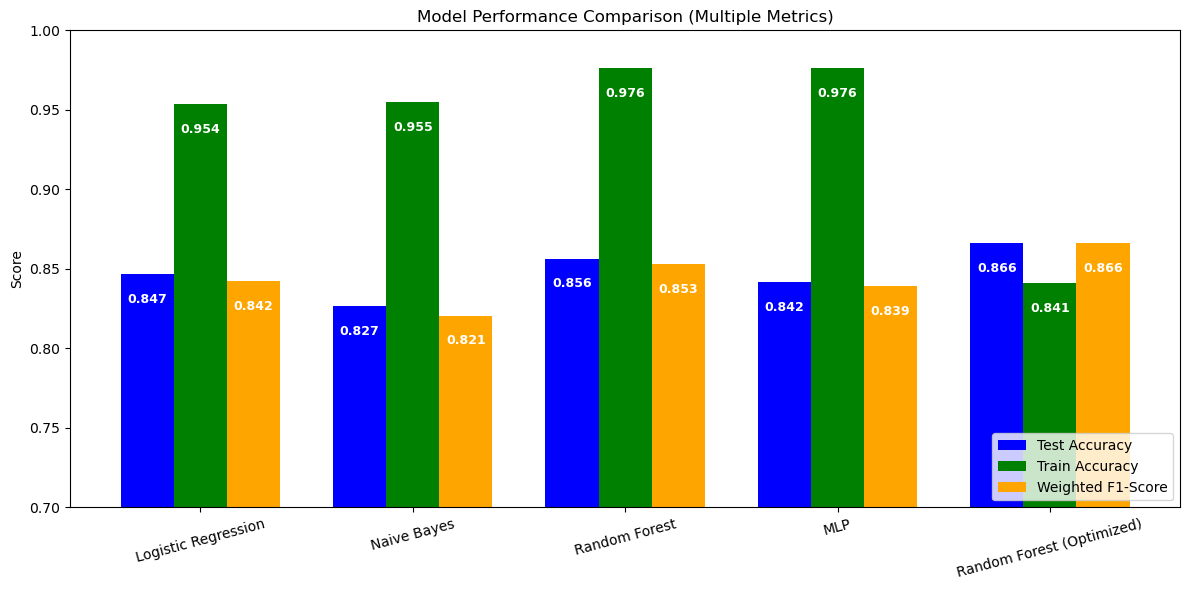


FINAL RESULTS SUMMARY
Best model: Random Forest (optimized via RandomizedSearchCV)
Best parameters found: {'n_estimators': 50, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 15}
Cross-validation accuracy: 0.8094
Test set accuracy: 0.8663
Test set weighted F1-score: 0.8664

Confusion Matrix (optimized Random Forest):
[[87  5]
 [22 88]]

Classification Report (optimized Random Forest):
              precision    recall  f1-score   support

         Ham       0.80      0.95      0.87        92
        Spam       0.95      0.80      0.87       110

    accuracy                           0.87       202
   macro avg       0.87      0.87      0.87       202
weighted avg       0.88      0.87      0.87       202


Predictions saved to 'predictions.csv'


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

# Set up paths
output_dir = '../output'
data_dir = '../data'

os.makedirs(output_dir, exist_ok=True)

# Training data in CSV format encoding in UTF-8
train_df = pd.read_csv(os.path.join(data_dir, 'Topic1-youtube_spam_train.csv'), encoding='utf-8')

# Test data in Excel format
test_df = pd.read_excel(os.path.join(data_dir, 'Topic1-youtube_spam_test.xlsx'))

print(f"Training data size: {train_df.shape}")
print(f"Test data size: {test_df.shape}")
print(f"\nTraining data columns: {train_df.columns.tolist()}")
print(f"Test data columns: {test_df.columns.tolist()}\n")

# Text cleaning before NLP
def clean_text(s):
    s = s.astype(str).str.lower()
    s = s.str.replace('ï»¿', '', regex=False)
    s = s.str.replace(r'http\S+|www\S+|@\w+|[^\w\s]|\d+', '', regex=True)
    s = s.str.replace(r'\s+', ' ', regex=True).str.strip()
    return s

train_df['cleaned'] = clean_text(train_df['TEXT'])
test_df['cleaned'] = clean_text(test_df['TEXT'])

# TF-IDF features
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2), stop_words='english')
X_train = tfidf.fit_transform(train_df['cleaned'])
X_test = tfidf.transform(test_df['cleaned'])
y_train = train_df['CLASS']
y_test = test_df['CLASS']

# Train and evaluate models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
}

print("="*60)
print("Model Evaluation with 5-fold Cross Validation")
print("="*60)

results = {}
for name, model in models.items():
    # Training time
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()
    
    # Training set evaluation
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    
    # Test set evaluation
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    # F1-score
    f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    results[name] = {
        'model': model, 
        'cv_mean': cv_mean, 
        'train_acc': train_acc, 
        'test_acc': test_acc,
        'f1_score': f1,
        'train_time': train_time
    }
    
    print(f"\n{name:-^50}")
    print(f"  Cross-validation accuracy: {cv_mean:.4f}")
    print(f"  Training accuracy: {train_acc:.4f}")
    print(f"  Test accuracy: {test_acc:.4f}")
    print(f"  Weighted F1-score: {f1:.4f}")
    print(f"  Training time: {train_time:.2f} seconds")
    print("  Confusion Matrix (test set):")
    print(confusion_matrix(y_test, y_test_pred))
    print("  Classification Report (test set):")
    print(classification_report(y_test, y_test_pred, target_names=['Ham', 'Spam']))
    print("\n" + "-"*50)
    
# Hyperparameter tuning for Random Forest
print("\n" + "="*60)
print("Hyperparameter Tuning for Random Forest")
print("="*60)

param_dist = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [5, 10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 3, 4, 5],
    'max_features': ['sqrt', 'log2', None]
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), 
    param_dist, 
    n_iter=20, 
    cv=5, 
    random_state=42
)
search.fit(X_train, y_train)

print(f"Best parameters: {search.best_params_}")
print(f"Best cross-validation accuracy: {search.best_score_:.4f}")

# Evaluate optimized model on test set
best_rf = search.best_estimator_

y_train_pred_best = best_rf.predict(X_train)
best_train_acc = accuracy_score(y_train, y_train_pred_best)

y_test_pred_best = best_rf.predict(X_test)
best_test_acc = accuracy_score(y_test, y_test_pred_best)

best_test_f1 = f1_score(y_test, y_test_pred_best, average='weighted')

results['Random Forest (Optimized)'] = {
    'train_acc': best_train_acc, 
    'test_acc': best_test_acc, 
    'f1_score': best_test_f1
}

print(f"\nOptimized Random Forest train accuracy: {best_train_acc:.4f}")
print(f"Optimized Random Forest test accuracy: {best_test_acc:.4f}")
print(f"Optimized Random Forest test weighted F1-score: {best_test_f1:.4f}")

# Improvement on Random Forest
print("\n" + "="*60)
print("Default vs Optimized Random Forest Comparison")
print("="*60)
print(f"Default RF test accuracy: {results['Random Forest']['test_acc']:.4f}")
print(f"Optimized RF test accuracy: {results['Random Forest (Optimized)']['test_acc']:.4f}")
print(f"Improvement: {results['Random Forest (Optimized)']['test_acc'] - results['Random Forest']['test_acc']:.4f} (+{(results['Random Forest (Optimized)']['test_acc'] - results['Random Forest']['test_acc'])*100:.2f}%)")

# Top 10 most important words for spam detection in random forest
feature_importance = best_rf.feature_importances_
feature_names = tfidf.get_feature_names_out()
top_indices = feature_importance.argsort()[-10:][::-1]

print("\n" + "="*60)
print("Top 10 Most Important Words for Spam Detection")
print("="*60)
for i, idx in enumerate(top_indices):
    print(f"{i+1}. '{feature_names[idx]}' (importance: {feature_importance[idx]:.4f})")

# Model comparison bar chart
print("\n" + "="*60)
print("Multi-metric Bar Chart Visualization")
print("="*60)

names = list(results.keys())
test_accuracies = [results[n]['test_acc'] for n in names]
train_accuracies = [results[n]['train_acc'] for n in names]
f1_scores = [results[n]['f1_score'] for n in names]

x = np.arange(len(names))
width = 0.25

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - width, test_accuracies, width, label='Test Accuracy', color='blue')
bars2 = plt.bar(x, train_accuracies, width, label='Train Accuracy', color='green')
bars3 = plt.bar(x + width, f1_scores, width, label='Weighted F1-Score', color='orange')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height - 0.02, 
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')

plt.ylabel('Score')
plt.title('Model Performance Comparison (Multiple Metrics)')
plt.xticks(x, names, rotation=15)
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'model_comparison.png'), dpi=150)
plt.show()

# Final results summary
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"Best model: Random Forest (optimized via RandomizedSearchCV)")
print(f"Best parameters found: {search.best_params_}")
print(f"Cross-validation accuracy: {search.best_score_:.4f}")
print(f"Test set accuracy: {best_test_acc:.4f}")
print(f"Test set weighted F1-score: {best_test_f1:.4f}")

print("\nConfusion Matrix (optimized Random Forest):")
print(confusion_matrix(y_test, y_test_pred_best))

print("\nClassification Report (optimized Random Forest):")
print(classification_report(y_test, y_test_pred_best, target_names=['Ham', 'Spam']))

# Save predictions
pd.DataFrame({'Predicted': y_test_pred_best}).to_csv(os.path.join(output_dir, 'predictions.csv'), index=False)
print("\nPredictions saved to 'predictions.csv'")